# Red Neuronal Convolucional (CNN) - Clasificador de Animales
### Clases: Ranas, Pájaros, Ballenas, Changos, Arañas

# 1. Importar Librerías

In [1]:
import numpy as np
import os
import re
import cv2
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

import tensorflow as tf
import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.layers import LeakyReLU
from tensorflow.keras.utils import to_categorical

print('TensorFlow version:', tf.__version__)
print('Keras version:', keras.__version__)

I0000 00:00:1779318738.131757    8026 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779318738.134477    8026 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1779318738.565693    8026 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version: 2.21.0
Keras version: 3.14.1


I0000 00:00:1779318739.591900    8026 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779318739.593768    8026 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


# 2. Cargar Imágenes del Dataset


In [ ]:
# Ruta a la carpeta principal del dataset
dirname = '/home/glowar23/Escritorio/IA/dataset_bueno'
imgpath = dirname + os.sep

images = []
labels = []

# Nombres de las clases (deben coincidir EXACTAMENTE con los nombres de las carpetas)
clases_nombres = ['ranas', 'pajaros', 'ballenas', 'changos', 'aranas']

print("Leyendo imágenes de:", imgpath)
print("-" * 50)

dircount = []  # guardará cuántas imágenes tiene cada clase

for idx, clase in enumerate(clases_nombres):
    folder = os.path.join(imgpath, clase)
    
    if not os.path.exists(folder):
        print(f"⚠️  ALERTA: No se encontró la carpeta '{clase}' en {folder}")
        continue
    
    contador = 0
    for filename in os.listdir(folder):
        if re.search(r"\.(jpg|jpeg|png|bmp|webp)$", filename, re.IGNORECASE):
            filepath = os.path.join(folder, filename)
            image = cv2.imread(filepath, cv2.IMREAD_COLOR)
            if image is not None:
                # Nos aseguramos que todas sean 35x35
                image = cv2.resize(image, (128, 128))
                images.append(image)
                labels.append(idx)
                contador += 1
    
    dircount.append(contador)
    print(f"Clase {idx} - {clase}: {contador} imágenes cargadas")

print("-" * 50)
print(f'✅ Total de imágenes cargadas: {len(images)}')

: 

# 3. Verificar Equilibrio del Dataset

=== EQUILIBRIO DEL DATASET ===
----------------------------------------
Clase 0 | ranas      |   8120 imágenes | ████████████████
Clase 1 | pajaros    |   8126 imágenes | ████████████████
Clase 2 | ballenas   |   8114 imágenes | ████████████████
Clase 3 | changos    |   8173 imágenes | ████████████████
Clase 4 | aranas     |   8275 imágenes | ████████████████
----------------------------------------
Total: 40808 imágenes
⚠️  Dataset DESBALANCEADO (mín: 8114, máx: 8275)


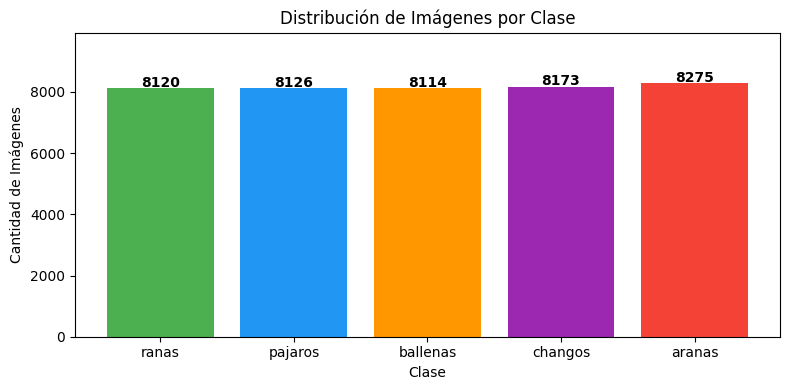

In [25]:
print("=== EQUILIBRIO DEL DATASET ===")
print("-" * 40)
for i, (clase, cantidad) in enumerate(zip(clases_nombres, dircount)):
    barra = '█' * (cantidad // 500)
    print(f"Clase {i} | {clase:<10} | {cantidad:>6} imágenes | {barra}")

print("-" * 40)
total = sum(dircount)
print(f"Total: {total} imágenes")

# Verificar si está balanceado
min_clase = min(dircount)
max_clase = max(dircount)
if max_clase - min_clase <= 100:
    print("✅ Dataset BALANCEADO (diferencia <= 100 imágenes entre clases)")
else:
    print(f"⚠️  Dataset DESBALANCEADO (mín: {min_clase}, máx: {max_clase})")

# Gráfica de equilibrio
plt.figure(figsize=(8, 4))
plt.bar(clases_nombres, dircount, color=['#4CAF50','#2196F3','#FF9800','#9C27B0','#F44336'])
plt.title('Distribución de Imágenes por Clase')
plt.xlabel('Clase')
plt.ylabel('Cantidad de Imágenes')
plt.ylim(0, max(dircount) * 1.2)
for i, v in enumerate(dircount):
    plt.text(i, v + 50, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

# 4. Convertir a Matrices Numpy

In [26]:
y = np.array(labels)
X = np.array(images, dtype=np.uint8)

# Reshape: (N, 35, 35) -> (N, 35, 35, 1)  [1 = escala de grises]
X = X.reshape(X.shape[0], 128, 128, 3)

classes = np.unique(y)
nClasses = len(classes)

print(f'Forma de X (imágenes): {X.shape}')
print(f'Forma de y (etiquetas): {y.shape}')
print(f'Número de clases: {nClasses}')
print(f'Clases: {list(zip(classes, clases_nombres))}')

Forma de X (imágenes): (40808, 128, 128, 3)
Forma de y (etiquetas): (40808,)
Número de clases: 5
Clases: [(np.int64(0), 'ranas'), (np.int64(1), 'pajaros'), (np.int64(2), 'ballenas'), (np.int64(3), 'changos'), (np.int64(4), 'aranas')]


# 5. Dividir en Sets de Entrenamiento y Prueba

In [27]:
# 80% entrenamiento, 20% prueba
train_X, test_X, train_Y, test_Y = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Set de Entrenamiento: {train_X.shape}  |  Etiquetas: {train_Y.shape}')
print(f'Set de Prueba:        {test_X.shape}   |  Etiquetas: {test_Y.shape}')

Set de Entrenamiento: (32646, 128, 128, 3)  |  Etiquetas: (32646,)
Set de Prueba:        (8162, 128, 128, 3)   |  Etiquetas: (8162,)


# 6. Visualizar Ejemplos del Dataset

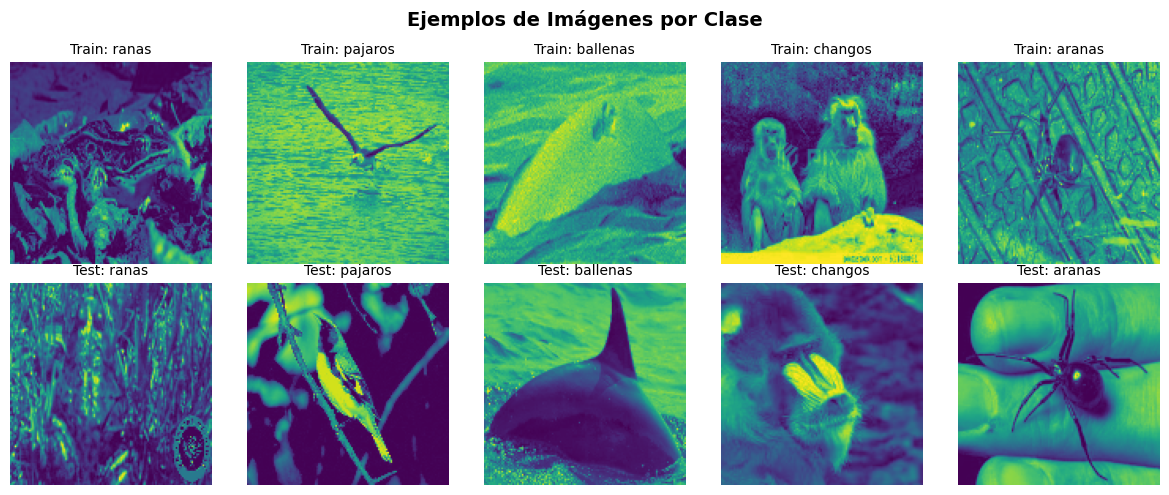

In [28]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('Ejemplos de Imágenes por Clase', fontsize=14, fontweight='bold')

for clase_idx in range(nClasses):
    idx = np.where(train_Y == clase_idx)[0][0]
    
    axes[0, clase_idx].imshow(train_X[idx, :, :, 0])
    axes[0, clase_idx].set_title(f'Train: {clases_nombres[clase_idx]}', fontsize=10)
    axes[0, clase_idx].axis('off')
    
    idx2 = np.where(test_Y == clase_idx)[0][0]
    axes[1, clase_idx].imshow(test_X[idx2, :, :, 0])
    axes[1, clase_idx].set_title(f'Test: {clases_nombres[clase_idx]}', fontsize=10)
    axes[1, clase_idx].axis('off')

plt.tight_layout()
plt.show()

# 7. Preprocesar las Imágenes (Normalización)

In [29]:
# Convertir a float y normalizar entre 0 y 1
train_X = train_X.astype('float32') / 255.0
test_X  = test_X.astype('float32')  / 255.0

print(f'Rango de valores - Mín: {train_X.min():.2f}, Máx: {train_X.max():.2f}')
print('✅ Imágenes normalizadas correctamente')

Rango de valores - Mín: 0.00, Máx: 1.00
✅ Imágenes normalizadas correctamente


# 8. One-Hot Encoding de Etiquetas

In [30]:
train_Y_one_hot = to_categorical(train_Y, num_classes=nClasses)
test_Y_one_hot  = to_categorical(test_Y,  num_classes=nClasses)

print('Etiqueta original (train_Y[0]):', train_Y[0], '->', clases_nombres[train_Y[0]])
print('One-hot encoding:', train_Y_one_hot[0])

Etiqueta original (train_Y[0]): 2 -> ballenas
One-hot encoding: [0. 0. 1. 0. 0.]


# 9. Crear Set de Validación

In [31]:
# Dividir el set de entrenamiento en entrenamiento (80%) y validación (20%)
train_X, valid_X, train_label, valid_label = train_test_split(
    train_X, train_Y_one_hot, test_size=0.2, random_state=48
)

print(f'Entrenamiento: {train_X.shape}  |  Labels: {train_label.shape}')
print(f'Validación:    {valid_X.shape}   |  Labels: {valid_label.shape}')
print(f'Prueba:        {test_X.shape}    |  Labels: {test_Y_one_hot.shape}')

Entrenamiento: (26116, 128, 128, 3)  |  Labels: (26116, 5)
Validación:    (6530, 128, 128, 3)   |  Labels: (6530, 5)
Prueba:        (8162, 128, 128, 3)    |  Labels: (8162, 5)


# 10. Crear el Modelo CNN

**Arquitectura:** 2 capas convolucionales + capas densas para clasificación

In [32]:
# Parámetros de entrenamiento
INIT_LR    = 1e-3   # Learning rate inicial
epochs     = 35    # 40 épocas para mejor precisión
batch_size = 64     # Imágenes por lote

In [33]:
# =============================================
#   ARQUITECTURA CNN - 2 CAPAS CONVOLUCIONALES
# =============================================
sport_model = Sequential(name='CNN_Animales')

# --- CAPA CONVOLUCIONAL 1 ---
sport_model.add(Conv2D(32, kernel_size=(3, 3), activation='linear',
                       padding='same', input_shape=(128, 128, 3)))
sport_model.add(LeakyReLU(alpha=0.1))
sport_model.add(MaxPooling2D((2, 2), padding='same'))
sport_model.add(Dropout(0.3))

# --- CAPA CONVOLUCIONAL 2 ---
sport_model.add(Conv2D(64, kernel_size=(3, 3), activation='linear', padding='same'))
sport_model.add(LeakyReLU(alpha=0.1))
sport_model.add(MaxPooling2D((2, 2), padding='same'))
sport_model.add(Dropout(0.3))

# --- CAPAS DENSAS (Clasificación final) ---
sport_model.add(Flatten())
sport_model.add(Dense(128, activation='linear'))
sport_model.add(LeakyReLU(alpha=0.1))
sport_model.add(Dropout(0.5))
sport_model.add(Dense(nClasses, activation='softmax'))

sport_model.summary()

/home/glowar23/Descargas/venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/glowar23/Descargas/venv/lib/python3.13/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "CNN_Animales"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     8,388,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,408,773 (32.08 MB)

 Trainable params: 8,408,773 (32.08 MB)

 Non-trainable params: 0 (0.00 B)

# 11. Compilar el Modelo

In [34]:
sport_model.compile(
    loss=keras.losses.categorical_crossentropy,
    optimizer=tf.keras.optimizers.Adam(learning_rate=INIT_LR),
    metrics=['accuracy']
)
print('✅ Modelo compilado correctamente')

✅ Modelo compilado correctamente


# 12. Entrenar el Modelo

> ⏳ Este paso puede tardar varios minutos dependiendo de tu CPU/GPU.

In [35]:
sport_train = sport_model.fit(
    train_X, train_label,
    batch_size=batch_size,
    epochs=epochs,
    verbose=1,
    validation_data=(valid_X, valid_label)
)

Epoch 1/35


E0000 00:00:1779337994.640952    8026 meta_optimizer.cc:967] remapper failed: INVALID_ARGUMENT: Mutation::Apply error: fanout 'StatefulPartitionedCall/gradient_tape/CNN_Animales_1/leaky_re_lu_4_1/LeakyRelu/LeakyReluGrad' exist for missing node 'StatefulPartitionedCall/CNN_Animales_1/conv2d_3_1/BiasAdd'.


409/409 ━━━━━━━━━━━━━━━━━━━━ 89s 212ms/step - accuracy: 0.5714 - loss: 1.1355 - val_accuracy: 0.6314 - val_loss: 1.0520
Epoch 2/35
409/409 ━━━━━━━━━━━━━━━━━━━━ 85s 209ms/step - accuracy: 0.7323 - loss: 0.7203 - val_accuracy: 0.7429 - val_loss: 0.7076
Epoch 3/35
409/409 ━━━━━━━━━━━━━━━━━━━━ 87s 213ms/step - accuracy: 0.7827 - loss: 0.5871 - val_accuracy: 0.7675 - val_loss: 0.6731
Epoch 4/35
409/409 ━━━━━━━━━━━━━━━━━━━━ 88s 214ms/step - accuracy: 0.8222 - loss: 0.4847 - val_accuracy: 0.8260 - val_loss: 0.5101
Epoch 5/35
409/409 ━━━━━━━━━━━━━━━━━━━━ 88s 216ms/step - accuracy: 0.8536 - loss: 0.3967 - val_accuracy: 0.7968 - val_loss: 0.6687
Epoch 6/35
409/409 ━━━━━━━━━━━━━━━━━━━━ 88s 216ms/step - accuracy: 0.8816 - loss: 0.3252 - val_accuracy: 0.7603 - val_loss: 0.8244
Epoch 7/35
409/409 ━━━━━━━━━━━━━━━━━━━━ 90s 221ms/step - accuracy: 0.8993 - loss: 0.2840 - val_accuracy: 0.8369 - val_loss: 0.5557
Epoch 8/35
409/409 ━━━━━━━━━━━━━━━━━━━━ 93s 226ms/step - accuracy: 0.9184 - loss: 0.2307 - val

# 13. Guardar el Modelo Entrenado

In [36]:
sport_model.save("modelo_cnn128.h5")
print("✅ Modelo guardado como: modelo_cnn128.h5")

✅ Modelo guardado como: modelo_cnn128.h5


# 14. Evaluar el Modelo

In [37]:
test_eval = sport_model.evaluate(test_X, test_Y_one_hot, verbose=1)
print(f'\nPérdida (Loss):   {test_eval[0]:.4f}')
print(f'Precisión (Acc):  {test_eval[1]*100:.2f}%')

256/256 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.8467 - loss: 0.8275

Pérdida (Loss):   0.8275
Precisión (Acc):  84.67%


# 15. Gráficas de Entrenamiento

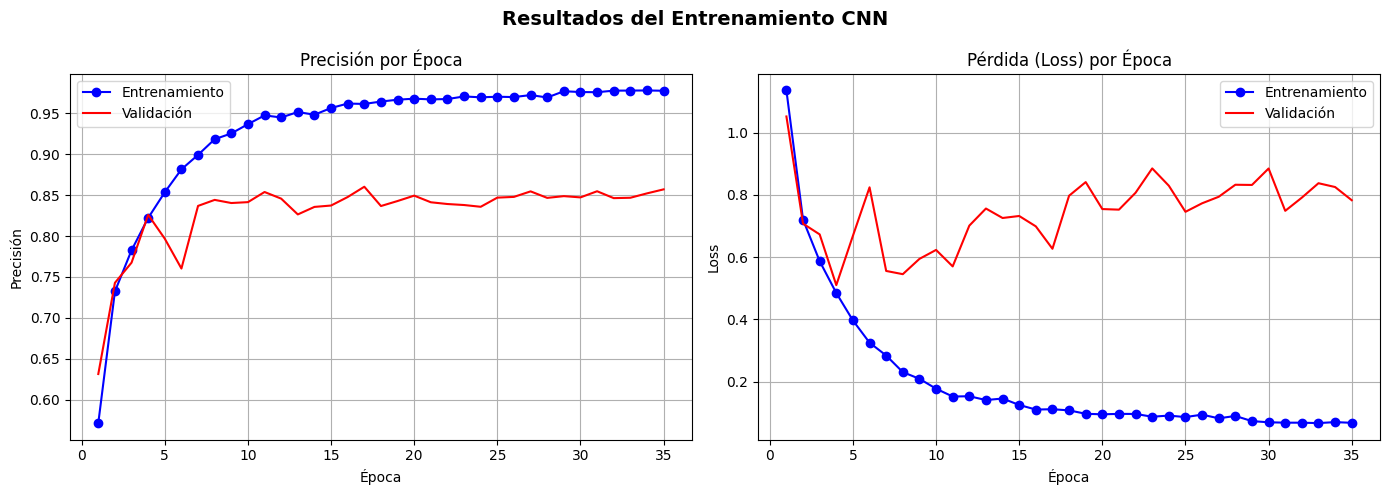

In [38]:
accuracy     = sport_train.history['accuracy']
val_accuracy = sport_train.history['val_accuracy']
loss         = sport_train.history['loss']
val_loss     = sport_train.history['val_loss']
epocas_rango = range(1, len(accuracy) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epocas_rango, accuracy,     'bo-', label='Entrenamiento')
ax1.plot(epocas_rango, val_accuracy, 'r-',  label='Validación')
ax1.set_title('Precisión por Época')
ax1.set_xlabel('Época')
ax1.set_ylabel('Precisión')
ax1.legend()
ax1.grid(True)

ax2.plot(epocas_rango, loss,     'bo-', label='Entrenamiento')
ax2.plot(epocas_rango, val_loss, 'r-',  label='Validación')
ax2.set_title('Pérdida (Loss) por Época')
ax2.set_xlabel('Época')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.suptitle('Resultados del Entrenamiento CNN', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 16. Reporte de Clasificación

In [39]:
predicted_probs   = sport_model.predict(test_X)
predicted_classes = np.argmax(predicted_probs, axis=1)

print("=== REPORTE DE CLASIFICACIÓN ===")
print(classification_report(test_Y, predicted_classes, target_names=clases_nombres))

256/256 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step
=== REPORTE DE CLASIFICACIÓN ===
              precision    recall  f1-score   support

       ranas       0.89      0.86      0.88      1624
     pajaros       0.85      0.69      0.76      1625
    ballenas       0.91      0.95      0.93      1623
     changos       0.86      0.88      0.87      1635
      aranas       0.74      0.85      0.79      1655

    accuracy                           0.85      8162
   macro avg       0.85      0.85      0.85      8162
weighted avg       0.85      0.85      0.85      8162



# 17. Ver Aciertos y Errores

Correctas:   6911
Incorrectas: 1251


/tmp/ipykernel_8026/3493664789.py:14: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/glowar23/Descargas/venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


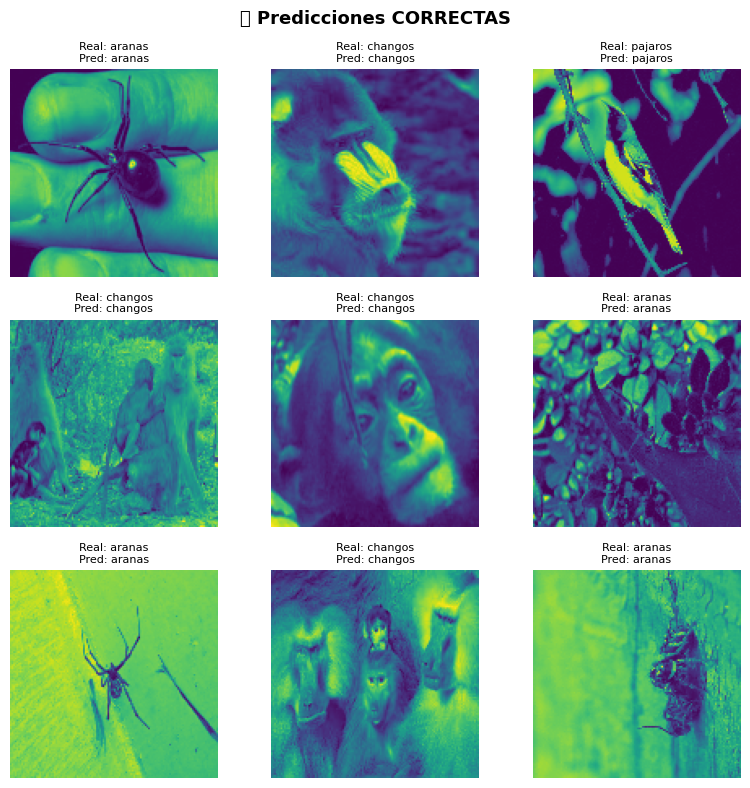

/tmp/ipykernel_8026/3493664789.py:26: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/glowar23/Descargas/venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


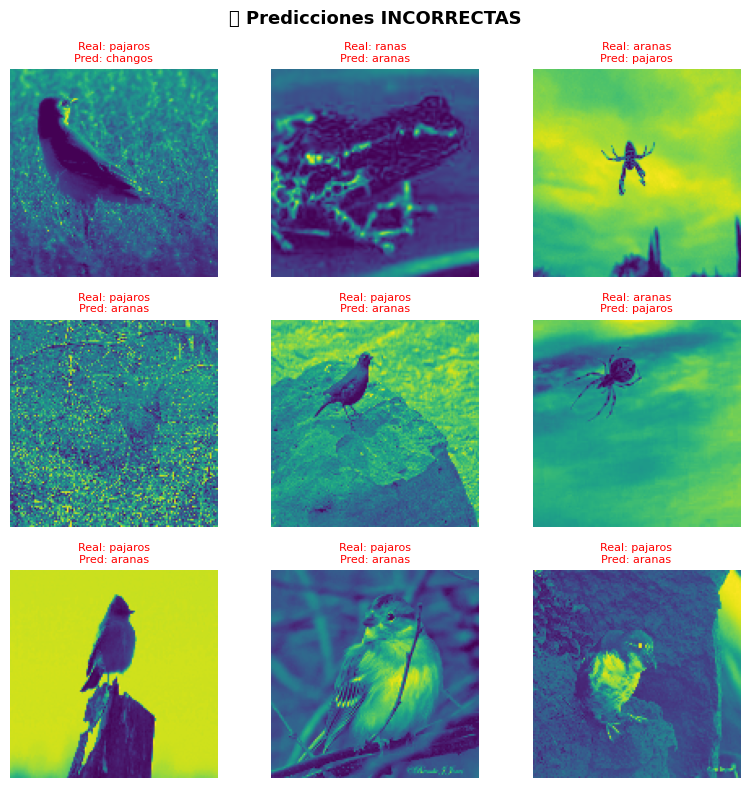

In [40]:
correct   = np.where(predicted_classes == test_Y)[0]
incorrect = np.where(predicted_classes != test_Y)[0]
print(f'Correctas:   {len(correct)}')
print(f'Incorrectas: {len(incorrect)}')

# Mostrar 9 aciertos
fig, axes = plt.subplots(3, 3, figsize=(8, 8))
fig.suptitle('✅ Predicciones CORRECTAS', fontsize=13, fontweight='bold')
for i, idx in enumerate(correct[:9]):
    ax = axes[i // 3, i % 3]
    ax.imshow(test_X[idx, :, :, 0])
    ax.set_title(f'Real: {clases_nombres[test_Y[idx]]}\nPred: {clases_nombres[predicted_classes[idx]]}', fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.show()

# Mostrar 9 errores
if len(incorrect) > 0:
    fig, axes = plt.subplots(3, 3, figsize=(8, 8))
    fig.suptitle('❌ Predicciones INCORRECTAS', fontsize=13, fontweight='bold')
    for i, idx in enumerate(incorrect[:9]):
        ax = axes[i // 3, i % 3]
        ax.imshow(test_X[idx, :, :, 0])
        ax.set_title(f'Real: {clases_nombres[test_Y[idx]]}\nPred: {clases_nombres[predicted_classes[idx]]}', fontsize=8, color='red')
        ax.axis('off')
    plt.tight_layout()
    plt.show()

---
# ════════════════════════════════════════
# 🔄 DESDE AQUÍ PUEDES EMPEZAR SIN REENTRENAR
# ════════════════════════════════════════
### Si reinicias el kernel, ejecuta solo las celdas 18 y 19

# 18. Cargar Modelo Guardado
### ▶️ Ejecuta esta celda PRIMERO si reinicias el kernel

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

# Cargamos el modelo ya entrenado
sport_model = load_model('modelo_cnn128.h5')

# Nombres de clases (siempre deben estar definidos)
clases_nombres = ['billete 100 pesos',
'billete 20 pesos',
'billete 50 pesos',
'billete 500 pesos',
'moneda 1 peso',
'moneda 10 pesos',
'moneda 2 pesos',
'moneda 5 pesos']

print('✅ Modelo cargado correctamente')
print('✅ Listo para identificar animales — ejecuta la celda 19')

: 

# 19. 🔍 Identificar una Imagen Nueva
### ▶️ Ejecuta esta celda cada vez que quieras identificar un animal
> Se abrirá una ventana para que **selecciones cualquier imagen de tu PC**

📂 3 imagen(es) encontrada(s)


🔍 Procesando imagen 1: /home/glowar23/Escritorio/IA/CNN-RGB/monedas/Sin título.jpeg


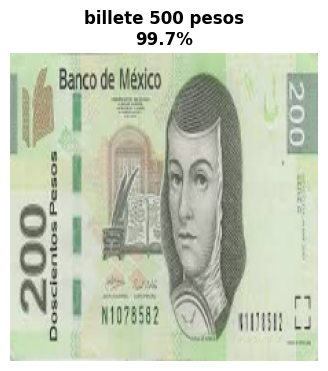

🐾 Resultado: BILLETE 500 PESOS (99.7%)
   Probabilidades:
   billete 100 pesos:   0.0% 
   billete 20 pesos:   0.1% 
   billete 50 pesos:   0.2% 
   billete 500 pesos:  99.7% █████████████████████████████
   moneda 1 peso:   0.0% 
   moneda 10 pesos:   0.0% 
   moneda 2 pesos:   0.0% 
   moneda 5 pesos:   0.0% 

🔍 Procesando imagen 2: /home/glowar23/Escritorio/IA/CNN-RGB/monedas/images.jpeg


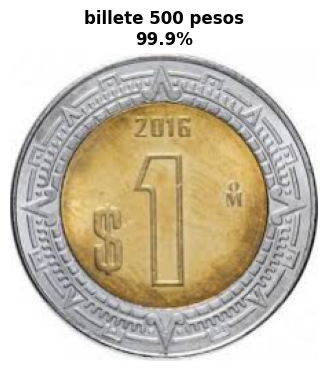

🐾 Resultado: BILLETE 500 PESOS (99.9%)
   Probabilidades:
   billete 100 pesos:   0.0% 
   billete 20 pesos:   0.0% 
   billete 50 pesos:   0.0% 
   billete 500 pesos:  99.9% █████████████████████████████
   moneda 1 peso:   0.0% 
   moneda 10 pesos:   0.0% 
   moneda 2 pesos:   0.0% 
   moneda 5 pesos:   0.0% 

🔍 Procesando imagen 3: /home/glowar23/Escritorio/IA/CNN-RGB/monedas/moneda-de-diez-pesos-mexicanos-4.webp


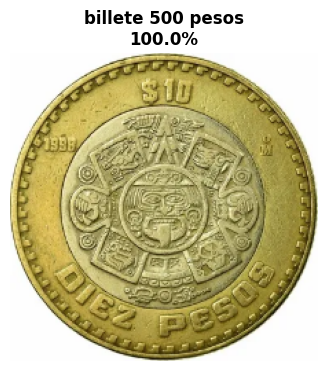

🐾 Resultado: BILLETE 500 PESOS (100.0%)
   Probabilidades:
   billete 100 pesos:   0.0% 
   billete 20 pesos:   0.0% 
   billete 50 pesos:   0.0% 
   billete 500 pesos: 100.0% █████████████████████████████
   moneda 1 peso:   0.0% 
   moneda 10 pesos:   0.0% 
   moneda 2 pesos:   0.0% 
   moneda 5 pesos:   0.0% 


In [ ]:
# =============================================
#   PREDICCIÓN DE IMÁGENES DESDE UNA RUTA ESPECÍFICA
# =============================================
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# 1. Define aquí la ruta de tu carpeta con imágenes
RUTA_DIRECTORIO = "/home/glowar23/Escritorio/IA/CNN-RGB/animales_prueba"

# 2. Obtener todas las imágenes válidas del directorio
extensiones_validas = {".jpg", ".jpeg", ".png", ".bmp", ".tiff", ".webp"}
carpeta = Path(RUTA_DIRECTORIO)

# Comprobar si la ruta existe
if not carpeta.exists() or not carpeta.is_dir():
    print(f"❌ La ruta no existe o no es una carpeta: {RUTA_DIRECTORIO}")
    imagenes = []
else:
    # Filtrar solo archivos con las extensiones válidas (ignorando mayúsculas/minúsculas)
    imagenes = [str(archivo) for archivo in carpeta.iterdir() 
                if archivo.is_file() and archivo.suffix.lower() in extensiones_validas]

# Verificar si se encontraron imágenes
if not imagenes:
    print(f"⚠️ No se encontraron imágenes en: {RUTA_DIRECTORIO}")
else:
    print(f"📂 {len(imagenes)} imagen(es) encontrada(s)\n")

    # Recorrer cada imagen
    for i, ruta in enumerate(imagenes):
        print(f"\n🔍 Procesando imagen {i+1}: {ruta}")

        img = cv2.imread(ruta, cv2.IMREAD_COLOR)

        if img is None:
            print("❌ No se pudo leer la imagen.")
            continue

        # Redimensionar
        img_resized = cv2.resize(img, (224, 224))

        # Preparar para el modelo
        img_array = img_resized.astype('float32') / 255.0
        img_array = img_array.reshape(1, 224, 224, 3)

        # Predecir (asumiendo que 'sport_model' y 'clases_nombres' ya están definidos)
        prediccion = sport_model.predict(img_array, verbose=0)
        clase_idx  = np.argmax(prediccion)
        confianza  = prediccion[0][clase_idx] * 100

        # Mostrar imagen
        plt.figure(figsize=(4, 4))
        plt.imshow(cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB))
        plt.title(
            f'{clases_nombres[clase_idx]}\n{confianza:.1f}%',
            fontsize=12,
            fontweight='bold'
        )
        plt.axis('off')
        plt.show()

        # Consola
        print(f'🐾 Resultado: {clases_nombres[clase_idx].upper()} ({confianza:.1f}%)')

        print('   Probabilidades:')
        for clase, prob in zip(clases_nombres, prediccion[0]):
            barra = '█' * int(prob * 30)
            print(f'   {clase:<10}: {prob*100:5.1f}% {barra}')